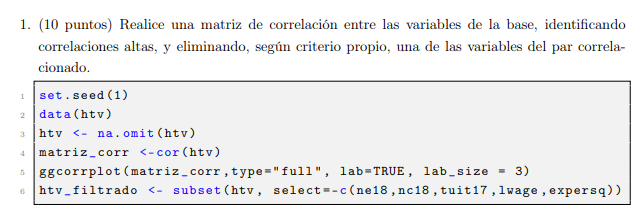

In [1]:
install.packages("wooldridge")
install.packages("ggcorrplot")
install.packages("ggplot2")

library(wooldridge)
library(ggcorrplot)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


     var1    var2 correlacion
1   lwage    wage       0.863
7      ne    ne18       0.881
8      nc    nc18       0.855
9   south south18       0.818
10   west  west18       0.798
12 tuit17  tuit18       0.981
14  exper expersq       0.982
Dimensiones de htv original:  1230 23 
Dimensiones de htv_filtrado: 1230 18 
Variables restantes:
 [1] "wage"     "abil"     "educ"     "ne"       "nc"       "west"    
 [7] "south"    "exper"    "motheduc" "fatheduc" "brkhme14" "sibs"    
[13] "urban"    "south18"  "west18"   "urban18"  "tuit18"   "ctuit"   


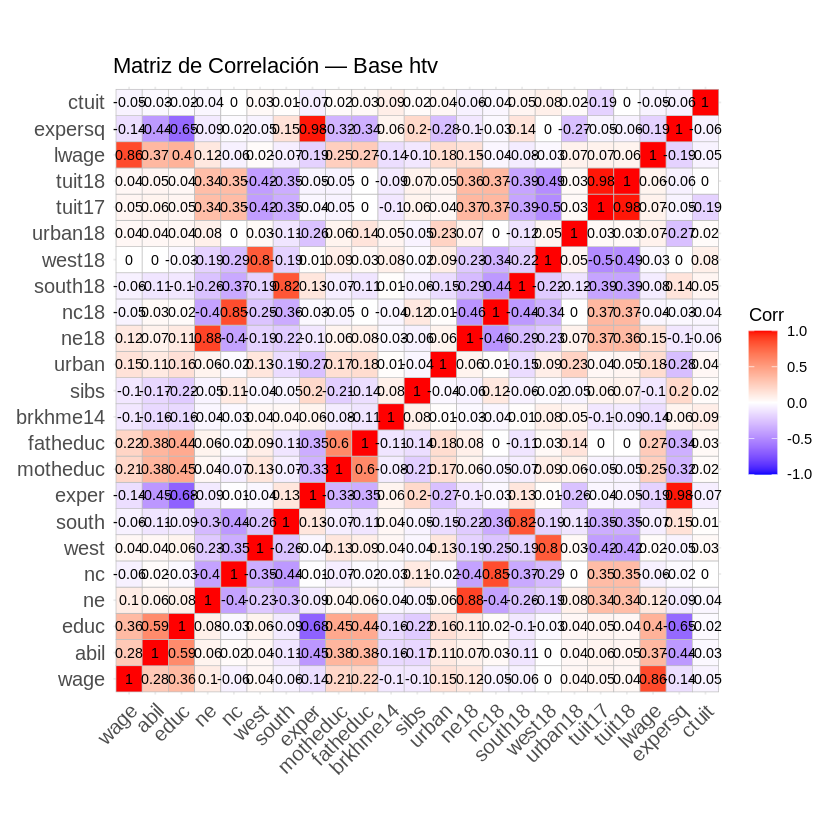

In [2]:
# PREGUNTA 1 — Matriz de Correlación (base htv)

set.seed(1)
data(htv)
htv <- na.omit(htv)

# Matriz de correlación
matriz_corr <- cor(htv)

# Visualización
ggcorrplot(matriz_corr,
           type     = "full",
           lab      = TRUE,
           lab_size = 3,
           title    = "Matriz de Correlación — Base htv")

# Tabla de pares con correlación alta (|r| > 0.75)
correlaciones_altas <- which(abs(matriz_corr) > 0.75 & matriz_corr != 1,
                              arr.ind = TRUE)
pares <- data.frame(
  var1        = rownames(matriz_corr)[correlaciones_altas[,1]],
  var2        = colnames(matriz_corr)[correlaciones_altas[,2]],
  correlacion = round(matriz_corr[correlaciones_altas], 3)
)
# Eliminar duplicados (el par aparece dos veces)
pares <- pares[pares$var1 < pares$var2, ]
print(pares)

# ============================================================
# FILTRADO: eliminación de variables altamente correlacionadas
# ============================================================
# Se eliminan: ne18, nc18, tuit17, lwage, expersq
htv_filtrado <- subset(htv, select = -c(ne18, nc18, tuit17, lwage, expersq))

# Verificar
cat("Dimensiones de htv original: ", dim(htv), "\n")
cat("Dimensiones de htv_filtrado:", dim(htv_filtrado), "\n")
cat("Variables restantes:\n")
print(names(htv_filtrado))

A partir de la matriz de estimación construida sobre la base htv , se identifican siete pares de variables con correlaciones superiores a 0.75 en valor absoluto, lo que constituye una señal de multicolinealidad potencialmente problemática para la estimación del modelo. Los pares detectados fueron: lwage/ wage(0.863), ne/ ne18(0.881), nc/ nc18(0.855), south/ south18(0.818), west/ west18(0.798), tuit17/ tuit18(0.981) y exper/ expersq(0.982).
El criterio de eliminación aplicado fue el siguiente: en los casos donde una variable es una transformación matemática directa de otra, se eliminó la transformada, pues no aporta información económica adicional sino que introduce redundancia artificial. Bajo este criterio se eliminaron lwage—que es simplemente el logaritmo de la variable dependiente wage— y expersq—que es el cuadrado de exper. En los casos donde el par corresponde a la misma variable medida en dos períodos distintos, se conservó la versión del período más reciente por ser más representativa de la situación actual del individuo, eliminando así ne18, nc18, south18, west18y tuit17. Como resultado, la base quedó reducida de 23 a 18 variables, preservando aquellas con mayor contenido informativo y relevancia económica para explicar el salario.



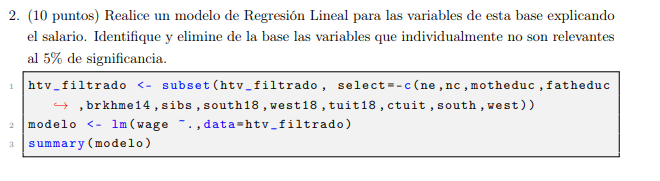

In [4]:
# ============================================================
# PREGUNTA 2 — Regresión Lineal + Eliminación por Significancia
# ============================================================

# Primer modelo con todas las variables del htv_filtrado
modelo <- lm(wage ~ ., data = htv_filtrado)
summary(modelo)


Call:
lm(formula = wage ~ ., data = htv_filtrado)

Residuals:
    Min      1Q  Median      3Q     Max 
-17.706  -4.377  -1.010   2.612  71.335 

Coefficients: (1 not defined because of singularities)
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -23.36404    3.59427  -6.500 1.17e-10 ***
abil          0.41854    0.13666   3.063  0.00224 ** 
educ          1.67509    0.16283  10.288  < 2e-16 ***
ne            1.00395    1.08439   0.926  0.35472    
nc           -0.71354    1.01789  -0.701  0.48344    
west          0.04498    1.25741   0.036  0.97147    
south              NA         NA      NA       NA    
exper         0.82719    0.11202   7.384 2.84e-13 ***
motheduc      0.02472    0.13561   0.182  0.85538    
fatheduc      0.12865    0.09419   1.366  0.17221    
brkhme14     -0.72774    0.64878  -1.122  0.26221    
sibs         -0.10950    0.13169  -0.832  0.40583    
urban         2.94273    0.65206   4.513 7.01e-06 ***
south18      -0.27209    1.08493  -0.251  0

In [5]:
htv_filtrado <- subset(htv_filtrado, select = -c(ne, nc, motheduc, fatheduc,
                                                  brkhme14, sibs, south18,
                                                  west18, tuit18, ctuit,
                                                  south, west))

modelo <- lm(wage ~ ., data = htv_filtrado)
summary(modelo)


Call:
lm(formula = wage ~ ., data = htv_filtrado)

Residuals:
    Min      1Q  Median      3Q     Max 
-17.758  -4.516  -1.011   2.520  70.895 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -23.7739     3.1340  -7.586 6.52e-14 ***
abil          0.4785     0.1337   3.578  0.00036 ***
educ          1.7927     0.1549  11.574  < 2e-16 ***
exper         0.8326     0.1109   7.505 1.17e-13 ***
urban         3.1371     0.6403   4.900 1.09e-06 ***
urban18       1.5137     0.7565   2.001  0.04562 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.22 on 1224 degrees of freedom
Multiple R-squared:  0.1841,	Adjusted R-squared:  0.1807 
F-statistic: 55.22 on 5 and 1224 DF,  p-value: < 2.2e-16


A partir del primer modelo de regresión lineal estimado con todas las variables de la base filtrada, se procedió a eliminar aquellas que no resultaron individualmente significativas al 5% de significancia, es decir, cuyo p-value asociado al test t superaba 0.05. Bajo este criterio se eliminaron las variables ne, nc, west, south, motheduc, fatheduc, brkhme14, sibs, south18, west18, tuit18y ctuit. Cabe destacar que southpresentó un coeficiente no definido debido a una singularidad, lo que indica que era combinación lineal exacta de otras variables presentes en el modelo, reforzando la decisión de excluirla.
El modelo resultante quedó conformado por las variables abil, educ, exper, urbany urban18, todas significativas al 5%. Los coeficientes estimados indican que la habilidad cognitiva, los años de educación, la experiencia laboral y residir en una zona urbana tienen efectos positivos y estadísticamente relevantes sobre el salario. El modelo explica aproximadamente un 18.4% de la varianza del salario (R² = 0.1841), con un R² ajustado de 0.1807 que penaliza por el número de variables incluidas. La significancia global del modelo es confirmada por el estadístico F = 55.22 con p-value < 2.2e-16, lo que permite rechazar la hipótesis nula de que todos los coeficientes son simultáneamente iguales a cero.

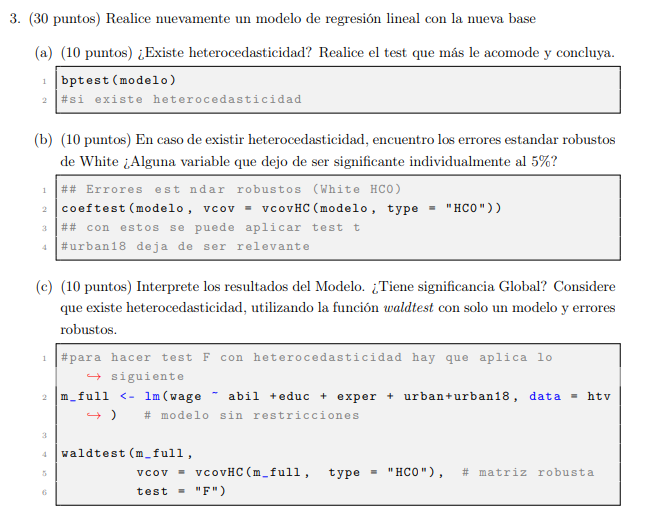

In [6]:
# ============================================================
# PREGUNTA 3a — Test de Heterocedasticidad (Breusch-Pagan)
# ============================================================

install.packages("lmtest")
install.packages("sandwich")

library(lmtest)
library(sandwich)

bptest(modelo)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric





	studentized Breusch-Pagan test

data:  modelo
BP = 58.514, df = 5, p-value = 2.464e-11


Para evaluar la presencia de heterocedasticidad en el modelo, se aplicó el test de Breusch-Pagan, cuya hipótesis nula establece que los errores del modelo son homocedásticos, es decir, que la varianza del término de error es constante para todas las observaciones. El resultado del test arrojó un estadístico BP = 58.514 con 5 grados de libertad y un p-value = 2.464e-11, valor extremadamente pequeño que se encuentra muy por debajo del nivel de significancia del 5%. Por lo tanto, se rechaza contundentemente la hipótesis nula de homocedasticidad, concluyendo que el modelo presenta heterocedasticidad. Esto implica que los errores estándar estimados por mínimos cuadrados ordinarios no son válidos, por lo que los tests ty F clásicos reportados en el resumen anterior no son confiables y deben ser corregidos mediante el uso de errores estándar robustos.

In [7]:
# ============================================================
# PREGUNTA 3b — Errores Estándar Robustos de White (HC0)
# ============================================================

coeftest(modelo, vcov = vcovHC(modelo, type = "HC0"))


t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) -23.77386    3.96121 -6.0017 2.569e-09 ***
abil          0.47854    0.10632  4.5009 7.412e-06 ***
educ          1.79274    0.21413  8.3722 < 2.2e-16 ***
exper         0.83260    0.12494  6.6638 4.025e-11 ***
urban         3.13710    0.48037  6.5306 9.582e-11 ***
urban18       1.51370    0.87057  1.7388   0.08233 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Ante la presencia de heterocedasticidad confirmada en la prueba anterior, se procedió a estimar los errores estándar robustos de White (HC0), los cuales corrigen la matriz de variaciones y covarianzas del modelo sin necesidad de conocer la forma específica de la heterocedasticidad. Al comparar los resultados con el modelo MCO original, se observa que los coeficientes estimados no cambian —pues la robustez solo afecta los errores estándar y no las estimaciones— pero sí se modifican los errores estándar, los estadísticos ty por ende los p-values ​​de cada variable.
El resultado más relevante es que la variable urban18deja de ser significativa al 5% con errores robustos, obteniendo un p-value de 0.082, quedando solo significativa al 10%. El resto de las variables del modelo — abil, educ, expery urban— mantienen su significancia individual al 1%, con valores de p muy por debajo de 0.05. Esto indica que, bajo una inferencia correctamente especificada que considera la heterocedasticidad presente en los datos, la variable urban18no aporta evidencia estadística suficiente para ser considerada individualmente relevante al nivel de significancia convencional del 5%.

In [8]:
# ============================================================
# PREGUNTA 3c — Significancia Global con Waldtest (HC0)
# ============================================================

m_full <- lm(wage ~ abil + educ + exper + urban + urban18, data = htv_filtrado)

waldtest(m_full,
         vcov = vcovHC(m_full, type = "HC0"),
         test = "F")

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,1224,NA,NA,NA
2,1229,-5,37.81602,3.754581e-36


Para evaluar la significancia global del modelo considerando la presencia de heterocedasticidad, se utilizó el test de Wald con errores estándar robustos de White (HC0), en reemplazo del test F clásico que asume homocedasticidad y que por tanto no es válido en este contexto. La hipótesis nula del test establece que todos los coeficientes del modelo son simultáneamente iguales a cero, es decir, que ninguna variable explica el salario. El resultado arrojó un estadístico F = 37.816 con 5 grados de libertad y un p-value = 3.754e-36, valor extremadamente cercano a cero que se encuentra muy por debajo de cualquier nivel de significancia convencional.
Por lo tanto, se rechaza contundentemente la hipótesis nula, concluyendo que el modelo tiene significancia global, es decir, que al menos una de las variables incluidas — abil, educ, exper, urbany urban18— contribuye de manera estadísticamente significativa a explicar el salario. En conjunto con los resultados anteriores, el modelo permite concluir que la habilidad cognitiva, los años de educación, la experiencia laboral y residir en una zona urbana son determinantes relevantes del salario, aun cuando se corrige por la heterocedasticidad presente en los datos.

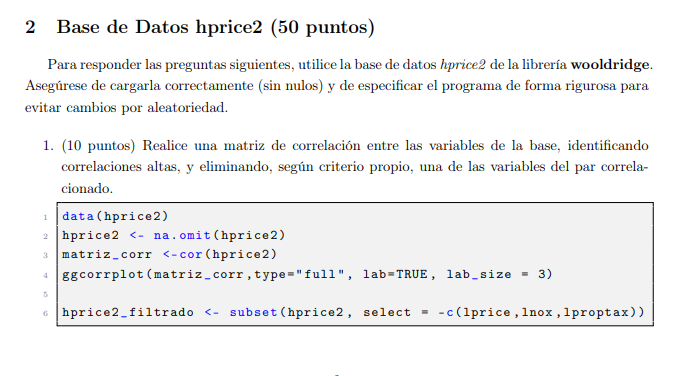

       var1    var2 correlacion
1    lprice   price       0.953
2      dist     nox      -0.770
3      lnox     nox       0.994
6   proptax  radial       0.910
7  lproptax  radial       0.864
9  lproptax proptax       0.989
12  lowstat  lprice      -0.791
14     dist    lnox      -0.809
Dimensiones originales: 506 12 
Dimensiones filtradas: 506 9 
Variables restantes:
[1] "price"   "crime"   "nox"     "rooms"   "dist"    "radial"  "proptax"
[8] "stratio" "lowstat"


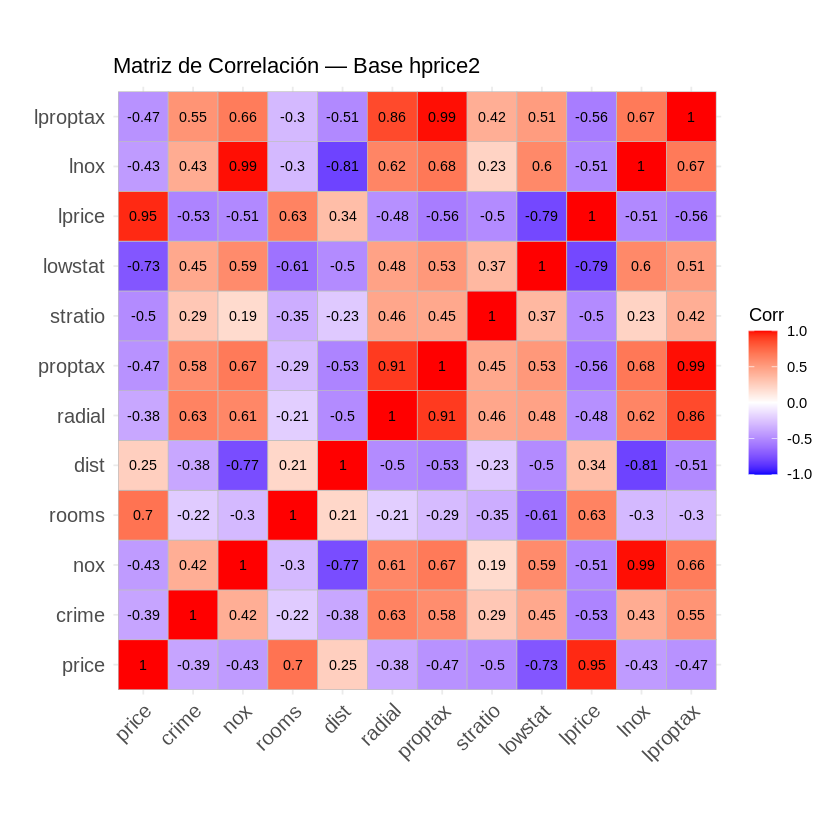

In [9]:
# ============================================================
# SECCIÓN 2 — BASE hprice2
# PREGUNTA 1 — Matriz de Correlación
# ============================================================

data(hprice2)
hprice2 <- na.omit(hprice2)

# Matriz de correlación
matriz_corr <- cor(hprice2)

# Visualización
ggcorrplot(matriz_corr,
           type     = "full",
           lab      = TRUE,
           lab_size = 3,
           title    = "Matriz de Correlación — Base hprice2")

# Tabla de pares con correlación alta (|r| > 0.75)
correlaciones_altas <- which(abs(matriz_corr) > 0.75 & matriz_corr != 1,
                              arr.ind = TRUE)
pares <- data.frame(
  var1        = rownames(matriz_corr)[correlaciones_altas[,1]],
  var2        = colnames(matriz_corr)[correlaciones_altas[,2]],
  correlacion = round(matriz_corr[correlaciones_altas], 3)
)
pares <- pares[pares$var1 < pares$var2, ]
print(pares)

# Filtrado
hprice2_filtrado <- subset(hprice2, select = -c(lprice, lnox, lproptax))

# Verificar
cat("Dimensiones originales:", dim(hprice2), "\n")
cat("Dimensiones filtradas:", dim(hprice2_filtrado), "\n")
cat("Variables restantes:\n")
print(names(hprice2_filtrado))

A partir de la matriz de estimación construida sobre la base hprice2 , se identifican siete pares de variables con correlaciones superiores a 0.75 en valor absoluto, indicando multicolinealidad potencialmente problemática para la estimación del modelo. Los pares detectados fueron: lprice/ price(0.953), dist/ nox(-0.770), lnox/ nox(0.994), proptax/ radial(0.910), lproptax/ radial(0.864), lproptax/ proptax(0.989), lowstat/ lprice(-0.791) y dist/ lnox(-0.809).
El criterio de eliminación aplicado fue el siguiente: en los casos donde una variable es una transformación logarítmica directa de otra, se eliminó la versión transformada conservando la variable en niveles, que resulta más directamente interpretable en términos económicos. Bajo este criterio se eliminaron lprice—transformación logarítmica de la variable dependiente price—, lnox—transformación logarítmica de nox— y lproptax—transformación logarítmica de proptax—. Esta decisión además resuelve indirectamente las correlaciones altas detectadas entre proptax/ radialy dist/ nox, al eliminar las versiones redundantes. Como resultado, la base quedó reducida de 12 a 9 variables, preservando aquellas con mayor contenido informativo y económico para explicar el precio de las viviendas.

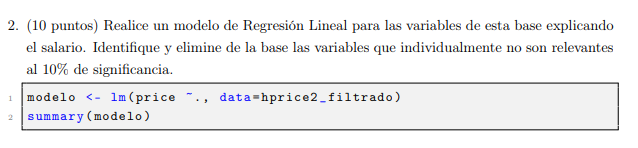

In [10]:
# ============================================================
# PREGUNTA 2 — Regresión Lineal + Eliminación por Significancia
# ============================================================

# Primer modelo con todas las variables
modelo <- lm(price ~ ., data = hprice2_filtrado)
summary(modelo)


Call:
lm(formula = price ~ ., data = hprice2_filtrado)

Residuals:
     Min       1Q   Median       3Q      Max 
-13096.0  -2988.4   -849.3   2063.6  27405.4 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 41533.99    5065.24   8.200 2.07e-15 ***
crime        -122.54      33.85  -3.621 0.000324 ***
nox         -1853.23     365.32  -5.073 5.54e-07 ***
rooms        4062.66     416.94   9.744  < 2e-16 ***
dist        -1231.39     167.96  -7.331 9.31e-13 ***
radial        293.17      65.95   4.445 1.08e-05 ***
proptax      -122.36      34.33  -3.564 0.000400 ***
stratio     -1102.70     125.89  -8.759  < 2e-16 ***
lowstat      -519.64      47.62 -10.912  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4953 on 497 degrees of freedom
Multiple R-squared:  0.7154,	Adjusted R-squared:  0.7108 
F-statistic: 156.1 on 8 and 497 DF,  p-value: < 2.2e-16


Se estimó un modelo de regresión lineal para explicar el precio de las viviendas ( price) utilizando todas las variables de la base filtrada. Al revisar la significancia individual de cada variable mediante el test t al 10% de significancia, se observa que todas las variables incluidas — crime, nox, rooms, dist, radial, proptax, stratioy lowstat— resultan estadísticamente significativas, con valores de p muy por debajo de 0.10. Por lo tanto, no se elimina ninguna variable del modelo y se procede con la especificación completa.
El modelo explica un 71,54% de la variación del precio de las viviendas (R² = 0,7154), con un R² ajustado de 0,7108, lo que indica un buen ajuste global. El estadístico F = 156,1 con valor p < 2,2e-16 confirma la significancia global del modelo. En términos económicos, variables como roomstienen un efecto positivo sobre el precio, mientras que nox, crime, dist, stratioy lowstatpresentan efectos negativos, lo que es consistente con la teoría económica: mayor contaminación, criminalidad, distancia al centro, tamaño de clases y porcentaje de población de bajos ingresos reducen el valor de las viviendas.

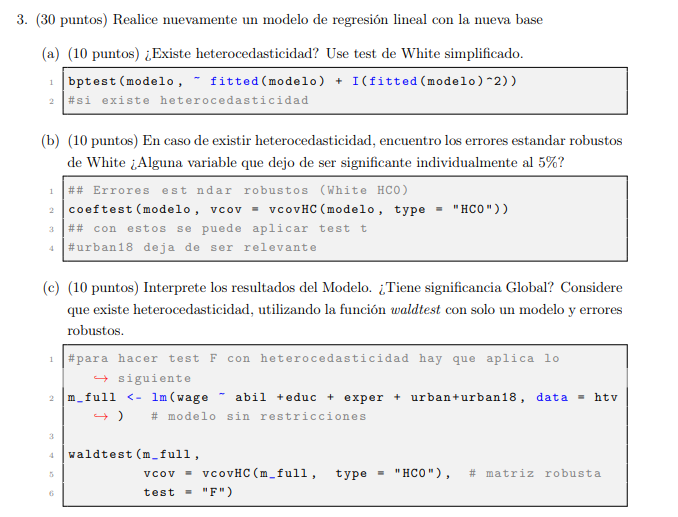

In [11]:
# ============================================================
# PREGUNTA 3a — Test de White Simplificado
# ============================================================

bptest(modelo, ~ fitted(modelo) + I(fitted(modelo)^2))


	studentized Breusch-Pagan test

data:  modelo
BP = 15.813, df = 2, p-value = 0.0003684


Para evaluar la presencia de heterocedasticidad en el modelo, se aplicó la prueba de White simplificado, que regresa los residuos al cuadrado sobre los valores ajustados y su cuadrado, capturando así formas generales de heterocedasticidad sin necesidad de especificar su forma funcional. La hipótesis nula del test establece que los errores son homocedásticos, es decir, que la variación del término de error es constante para todas las observaciones. El resultado arrojó un estadístico BP = 15.813 con 2 grados de libertad y un p-value = 0.0003684, valor muy por debajo del nivel de significancia del 5%. Por lo tanto, se rechaza la hipótesis nula de homocedasticidad, concluyendo que el modelo presenta heterocedasticidad. Esto implica que los errores estándar estimados por mínimos cuadrados ordinarios no son confiables, por lo que los tests ty F clásicos reportados anteriormente son inválidos y deben corregirse mediante el uso de errores estándar robustos de White.

In [12]:
# ============================================================
# PREGUNTA 3b — Errores Estándar Robustos de White (HC0)
# ============================================================

coeftest(modelo, vcov = vcovHC(modelo, type = "HC0"))


t test of coefficients:

             Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 41533.992   7384.087  5.6248 3.104e-08 ***
crime        -122.544     24.292 -5.0447 6.380e-07 ***
nox         -1853.227    330.761 -5.6029 3.496e-08 ***
rooms        4062.658    753.102  5.3946 1.065e-07 ***
dist        -1231.388    187.471 -6.5684 1.285e-10 ***
radial        293.167     63.182  4.6401 4.461e-06 ***
proptax      -122.361     28.423 -4.3050 2.012e-05 ***
stratio     -1102.697    110.573 -9.9726 < 2.2e-16 ***
lowstat      -519.637     89.161 -5.8281 1.009e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Ante la presencia de heterocedasticidad confirmada en la prueba anterior, se procedió a estimar los errores estándar robustos de White (HC0), los cuales corrigen la matriz de varianzas y covarianzas sin necesidad de conocer la forma específica de la heterocedasticidad. Al comparar los resultados con el modelo MCO original, se observa que los coeficientes estimados se mantienen idénticos (pues la robustez no afecta las estimaciones puntuales) pero los errores estándar se modifican, alterando los estadísticos ty p-values ​​de cada variable.
A diferencia de lo ocurrido en la Sección 1, en este caso ninguna variable pierde su significancia individual al 5% tras aplicar los errores robustos de White. Todas las variables del modelo (crime, nox, rooms, dist, radial, proptax, stratioy lowstat) mantienen valores p muy por debajo de 0.05, confirmando su relevancia individual incluso bajo una inferencia correctamente especificada que considera la heterocedasticidad presente en los datos. Esto sugiere que, si bien existe heterocedasticidad en el modelo, su efecto sobre la inferencia no es suficientemente grave como para cambiar las conclusiones respecto a la significancia de las variables explicativas del precio de las viviendas.

In [14]:
# ============================================================
# PREGUNTA 3c — Significancia Global con Waldtest (HC0)
# ============================================================

m_full <- lm(price ~ crime + nox + rooms + dist + radial + proptax +
             stratio + lowstat, data = hprice2_filtrado)

waldtest(m_full,
         vcov = vcovHC(m_full, type = "HC0"),
         test = "F")

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,497,NA,NA,NA
2,505,-8,130.3504,7.454498e-117


Para evaluar la significancia global del modelo considerando la presencia de heterocedasticidad, se utilizó el test de Wald con errores estándar robustos de White (HC0), en reemplazo del test F clásico que asume homocedasticidad y que por tanto no es válido en este contexto. La hipótesis nula del test establece que todos los coeficientes del modelo son simultáneamente iguales a cero, es decir, que ninguna variable contribuye a explicar el precio de las viviendas. El resultado arrojó un estadístico F = 130.35 con 8 grados de libertad y un p-value = 7.454e-117, valor extraordinariamente cercano a cero que se encuentra muy por debajo de cualquier nivel de significancia convencional.
Por lo tanto, se rechaza contundentemente la hipótesis nula, concluyendo que el modelo tiene significancia global bajo inferencia robusta. En conjunto con los resultados anteriores, es posible concluir que las variables crime, nox, rooms, dist, radial, proptax, stratioy lowstatexplican de manera conjunta y estadísticamente significativa el precio de las viviendas, aun corrigiendo por la heterocedasticidad presente en los datos. El modelo presenta además un buen ajuste con un R² de 0.7154, lo que indica que aproximadamente el 71.5% de la variabilidad del precio de las viviendas queda explicada por las variables incluidas.